In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 502 files belonging to 4 classes.
Using 402 files for training.
Found 502 files belonging to 4 classes.
Using 100 files for validation.


In [12]:
class_names = train_ds.class_names

print(class_names)

['can', 'paper', 'plastic', 'vinyl']


In [13]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 5s/step - accuracy: 0.2587 - loss: 5.3945 - val_accuracy: 0.3000 - val_loss: 1.3305
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.4179 - loss: 1.2249 - val_accuracy: 0.3600 - val_loss: 1.5655
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.5174 - loss: 1.0757 - val_accuracy: 0.5400 - val_loss: 1.1860
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 71s 5s/step - accuracy: 0.5945 - loss: 0.8701 - val_accuracy: 0.5400 - val_loss: 1.3318
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.7264 - loss: 0.6853 - val_accuracy: 0.5200 - val_loss: 1.2747


In [16]:
loss, acc = model.evaluate(val_ds)

print("Accuracy :", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5200 - loss: 1.2747
Accuracy : 0.5199999809265137


In [23]:
import os

save_path = "/content/drive/MyDrive/OSS/AI/model/recycle_model.keras"

# Check if the directory exists, and create it if not
os.makedirs(os.path.dirname(save_path), exist_ok=True)

model.save(save_path)

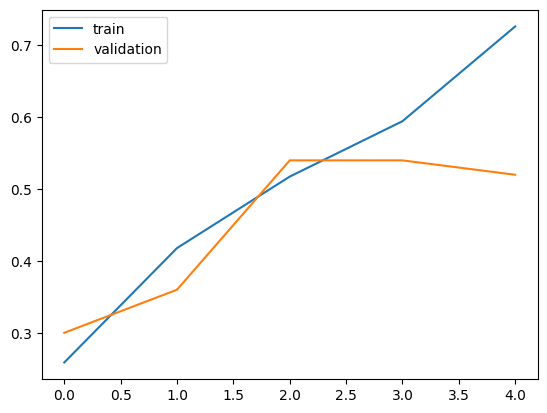

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train','validation'])
plt.show()

In [22]:
import os

# 디렉토리 내용 확인
model_dir = os.path.dirname(save_path)
print(f"Checking contents of: {model_dir}")
if os.path.exists(model_dir):
    print(os.listdir(model_dir))
else:
    print("The directory does not exist.")

Checking contents of: /content/drive/MyDrive/OSS/model
The directory does not exist.
